# Schedule and Equal-Budget Validation

This notebook investigates whether the detected Parrondo-type reversal is
caused specifically by alternating Policy A and Policy B.

Three questions are examined:

1. Are periodic AB and BA sequences better than block sequences containing
   the same 50 A and 50 B calls?
2. Are periodic sequences better than randomly ordered sequences containing
   exactly 50 A and 50 B calls?
3. Does the advantage remain when every strategy is limited to the same
   treatment budget?

These controls distinguish a scheduling effect from a more general mixture
of complementary policies or additional treatment expenditure.

In [1]:
# Resolve the repository from this notebook's directory or the repository root.
from pathlib import Path
import os
import sys
_start = Path.cwd().resolve()
repo_root = next(p for p in (_start, *_start.parents) if (p / "src" / "weed_ca.py").is_file())
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from pathlib import Path
import os


# Locate the repository root from the notebook directory.
current_path = Path.cwd().resolve()

repo_root = next(
    path
    for path in (current_path, *current_path.parents)
    if (path / "src").is_dir()
)

os.chdir(repo_root)

print(f"Repository root: {repo_root}")
print(f"Current directory: {Path.cwd()}")

Repository root: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model
Current directory: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model


## Import the corrected simulator and policies

The simulator is reloaded before the experiment runner so that the corrected
non-periodic diffusion boundary is used.

In [2]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import src.weed_ca
import src.weed_experiment
import src.weed_policies

importlib.reload(src.weed_ca)
importlib.reload(src.weed_policies)
importlib.reload(src.weed_experiment)

from src.weed_experiment import (
    ExperimentConfig,
    run_experiment,
)

from src.weed_policies import (
    HighDensityRemovalPolicy,
    SpreadFrontRemovalPolicy,
)

c:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\cits4403_weed_env_01\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the representative Parrondo condition

The representative condition is selected automatically from conditions that
satisfy both AB and BA. The selection maximises the weakest of the four
required inequalities.

In [3]:
results_path = (
    repo_root
    / "results"
    / "parrondo_parameter_search.csv"
)

search_results = pd.read_csv(results_path)

both_mask = (
    search_results["ab_parrondo"].astype(bool)
    & search_results["ba_parrondo"].astype(bool)
)

both_results = search_results[both_mask].copy()

if both_results.empty:
    raise RuntimeError(
        "No condition satisfies both AB and BA."
    )

both_results["combined_margin"] = np.minimum.reduce(
    [
        both_results["a_relative_change"].to_numpy(),
        both_results["b_relative_change"].to_numpy(),
        -both_results["ab_relative_change"].to_numpy(),
        -both_results["ba_relative_change"].to_numpy(),
    ]
)

representative_row = (
    both_results
    .sort_values("combined_margin", ascending=False)
    .iloc[0]
)

parameters = {
    "a_removal_rate": float(
        representative_row["a_removal_rate"]
    ),
    "b_removal_rate": float(
        representative_row["b_removal_rate"]
    ),
    "max_cells": int(
        representative_row["max_cells"]
    ),
    "boundary": float(
        representative_row["boundary"]
    ),
    "b_lower_threshold": float(
        representative_row["b_lower_threshold"]
    ),
}

parameters

{'a_removal_rate': 0.2,
 'b_removal_rate': 0.5,
 'max_cells': 100,
 'boundary': 0.75,
 'b_lower_threshold': 0.5}

## Load the Perth metropolitan data and common configuration

Every schedule starts from the same initial grid and uses 100 simulation
steps. Only the ordering of Policy A and Policy B changes.

In [4]:
from utils.data_loader import load_locality_data


localities = load_locality_data()

metro = localities[
    localities["postcode"]
    .astype(int)
    .between(6000, 6199)
].copy()

config = ExperimentConfig(
    pressure_coef=0.000783,
    cell_size=1000.0,
    w_min=0.05,
    w_max=1.0,
    growth_rate=0.02,
    diffusion_rate=0.01,
    carrying_capacity=1.0,
    steps=100,
    high_density_threshold=0.7,
    crs="EPSG:7850",
)

print(f"Polygons: {len(metro)}")
print(f"Simulation steps: {config.steps}")

Polygons: 375
Simulation steps: 100


C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\src\data_loader.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  census["postcode"] = (


## Define policy factories

Fresh policy objects are created for every run so that no mutable state is
shared between schedules.

In [5]:
UNIT_COST = 200.0


def make_policy_a():
    return HighDensityRemovalPolicy(
        threshold=parameters["boundary"],
        removal_rate=parameters["a_removal_rate"],
        max_cells=parameters["max_cells"],
        unit_cost=UNIT_COST,
    )


def make_policy_b():
    return SpreadFrontRemovalPolicy(
        lower_threshold=parameters["b_lower_threshold"],
        upper_threshold=parameters["boundary"],
        removal_rate=parameters["b_removal_rate"],
        max_cells=parameters["max_cells"],
        unit_cost=UNIT_COST,
    )

## Define an explicit schedule policy

`ScheduledPolicy` applies one entry from a fixed schedule per simulation
step. This supports periodic, block and random schedules while keeping the
number of A and B calls exactly controlled.

In [6]:
class ScheduledPolicy:
    '''Apply Policy A and Policy B according to a fixed schedule.'''

    def __init__(self, policy_a, policy_b, schedule):
        if not callable(policy_a) or not callable(policy_b):
            raise TypeError("Both policies must be callable")

        self.policy_a = policy_a
        self.policy_b = policy_b
        self.schedule = tuple(schedule)

        if not self.schedule:
            raise ValueError("schedule cannot be empty")

        if not set(self.schedule).issubset({"A", "B"}):
            raise ValueError(
                "schedule can contain only 'A' and 'B'"
            )

        self._call_count = 0

    @property
    def call_count(self):
        return self._call_count

    def reset(self):
        self._call_count = 0

    def __call__(self, weed_grid, valid_mask):
        if self._call_count >= len(self.schedule):
            raise RuntimeError(
                "Policy was called more times than the schedule length"
            )

        policy_name = self.schedule[self._call_count]

        if policy_name == "A":
            policy = self.policy_a
        else:
            policy = self.policy_b

        diff, cost = policy(weed_grid, valid_mask)
        self._call_count += 1

        return diff, cost

## Construct deterministic and random schedules

All mixed schedules contain exactly 50 A calls and 50 B calls.

- AB alternates and starts with A;
- BA alternates and starts with B;
- A50B50 uses one block of A followed by one block of B;
- B50A50 uses one block of B followed by one block of A;
- random schedules shuffle the same 50 A and 50 B calls.

In [7]:
steps = config.steps
half_steps = steps // 2

if steps % 2 != 0:
    raise ValueError(
        "This notebook requires an even number of steps"
    )

schedules = {
    "A only": ["A"] * steps,
    "B only": ["B"] * steps,
    "AB": ["A", "B"] * half_steps,
    "BA": ["B", "A"] * half_steps,
    "A50B50": (
        ["A"] * half_steps
        + ["B"] * half_steps
    ),
    "B50A50": (
        ["B"] * half_steps
        + ["A"] * half_steps
    ),
}

for name, schedule in schedules.items():
    print(
        f"{name}: A={schedule.count('A')}, "
        f"B={schedule.count('B')}"
    )

A only: A=100, B=0
B only: A=0, B=100
AB: A=50, B=50
BA: A=50, B=50
A50B50: A=50, B=50
B50A50: A=50, B=50


In [8]:
def run_schedule(name, schedule, policy_wrapper=None):
    '''Run one fixed schedule.'''

    scheduled_policy = ScheduledPolicy(
        policy_a=make_policy_a(),
        policy_b=make_policy_b(),
        schedule=schedule,
    )

    if policy_wrapper is not None:
        active_policy = policy_wrapper(scheduled_policy)
    else:
        active_policy = scheduled_policy

    result = run_experiment(
        name=name,
        gdf=metro,
        config=config,
        policy=active_policy,
    )

    return result


def summarise_result(name, result):
    '''Return metrics used by the schedule comparison.'''

    cumulative_weed = float(
        np.trapezoid(result.mean_weed)
    )

    return {
        "strategy": name,
        "initial_mean": result.initial_mean,
        "final_mean": result.final_mean,
        "relative_change": result.relative_change,
        "winning": result.relative_change < 0,
        "high_density_cells": (
            result.final_high_density_cells
        ),
        "cumulative_weed": cumulative_weed,
        "final_cost": result.final_cost,
    }

## Run the unrestricted deterministic schedules

This comparison tests whether periodic alternation is better than applying
the same numbers of A and B calls in two large blocks.

In [9]:
baseline_result = run_experiment(
    name="schedule_baseline",
    gdf=metro,
    config=config,
)

deterministic_results = {
    "Baseline": baseline_result,
}

for name, schedule in tqdm(
    schedules.items(),
    total=len(schedules),
    desc="Deterministic schedules",
):
    deterministic_results[name] = run_schedule(
        name=name,
        schedule=schedule,
    )

deterministic_summary = pd.DataFrame(
    [
        summarise_result(name, result)
        for name, result
        in deterministic_results.items()
    ]
)

deterministic_summary

Deterministic schedules: 100%|██████████| 6/6 [00:01<00:00,  4.15it/s]


,strategy,initial_mean,final_mean,relative_change,winning,high_density_cells,cumulative_weed,final_cost
0,Baseline,0.860575,0.981424,0.140429,False,6933,93.568291,0.00000
1,A only,0.860575,0.867618,0.008184,False,6933,85.623657,386340.21875
2,B only,0.860575,0.870770,0.011848,False,5474,86.119209,294982.84375
3,AB,0.860575,0.825061,-0.041267,True,5616,83.317772,456683.56250
4,BA,0.860575,0.822475,-0.044273,True,5576,83.153107,458628.90625
5,A50B50,0.860575,0.908853,0.056101,False,6373,86.630898,277365.28125
6,B50A50,0.860575,0.853722,-0.007963,True,6348,85.492783,354242.87500


## Compare periodic and block schedules

If AB and BA are winning while A50B50 and B50A50 are losing, periodic
alternation itself is important.

If all mixed schedules are similarly successful, the result is better
described as complementary policy mixing rather than an alternation-specific
effect.

In [10]:
individual_losing = (
    deterministic_results["A only"].relative_change > 0
    and deterministic_results["B only"].relative_change > 0
)

periodic_winning = {
    name: deterministic_results[name].relative_change < 0
    for name in ["AB", "BA"]
}

block_winning = {
    name: deterministic_results[name].relative_change < 0
    for name in ["A50B50", "B50A50"]
}

alternation_specific = (
    individual_losing
    and any(periodic_winning.values())
    and not any(block_winning.values())
)

print(f"A and B individually losing: {individual_losing}")
print(f"Periodic winning: {periodic_winning}")
print(f"Block winning: {block_winning}")
print(
    "Alternation-specific result: "
    f"{alternation_specific}"
)

A and B individually losing: True
Periodic winning: {'AB': True, 'BA': True}
Block winning: {'A50B50': False, 'B50A50': True}
Alternation-specific result: False


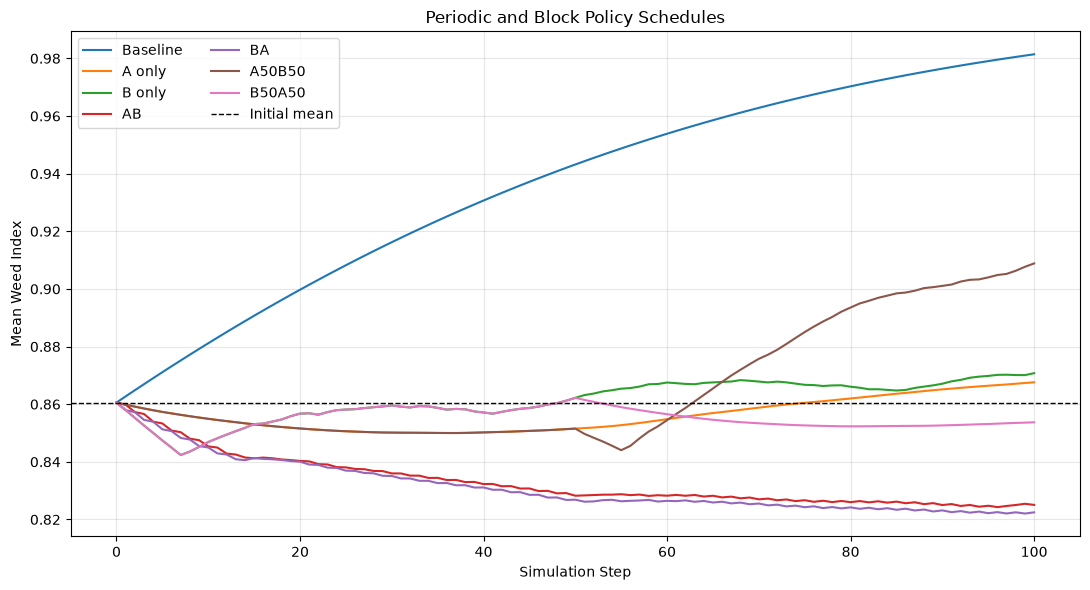

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))

for name, result in deterministic_results.items():
    ax.plot(
        np.arange(len(result.mean_weed)),
        result.mean_weed,
        label=name,
    )

ax.axhline(
    baseline_result.initial_mean,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Initial mean",
)

ax.set_title("Periodic and Block Policy Schedules")
ax.set_xlabel("Simulation Step")
ax.set_ylabel("Mean Weed Index")
ax.grid(alpha=0.3)
ax.legend(ncol=2)

plt.tight_layout()
plt.show()

## Compare random schedules

Each random schedule contains exactly 50 A calls and 50 B calls. Only their
order changes.

Twenty fixed random seeds are used so that the experiment is reproducible.

In [12]:
RANDOM_SEEDS = list(range(20))

random_records = []
random_mean_histories = {}

for seed in tqdm(
    RANDOM_SEEDS,
    desc="Random schedules",
    unit="seed",
):
    rng = np.random.default_rng(seed)

    random_schedule = np.array(
        ["A"] * half_steps
        + ["B"] * half_steps
    )

    rng.shuffle(random_schedule)

    result = run_schedule(
        name=f"random_{seed}",
        schedule=random_schedule.tolist(),
    )

    record = summarise_result(
        f"Random {seed}",
        result,
    )

    record["seed"] = seed
    random_records.append(record)
    random_mean_histories[seed] = (
        result.mean_weed.copy()
    )

random_summary = pd.DataFrame(random_records)

random_summary.describe()

Random schedules: 100%|██████████| 20/20 [00:05<00:00,  3.61seed/s]


,initial_mean,final_mean,relative_change,high_density_cells,cumulative_weed,final_cost,seed
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.00000
mean,0.860575,0.828829,-0.036889,5631.500000,83.531921,443891.532813,9.50000
std,0.000000,0.005449,0.006332,48.376266,0.312905,12560.655170,5.91608
min,0.860575,0.820876,-0.046130,5553.000000,83.102364,416185.000000,0.00000
25%,0.860575,0.823826,-0.042702,5589.500000,83.279747,436130.101562,4.75000
50%,0.860575,0.828559,-0.037203,5634.000000,83.518448,444953.453125,9.50000
75%,0.860575,0.832875,-0.032188,5661.500000,83.747787,451369.062500,14.25000
max,0.860575,0.841430,-0.022246,5731.000000,84.337410,467375.593750,19.00000


In [13]:
random_winning_fraction = float(
    random_summary["winning"].mean()
)

print(
    f"Winning random schedules: "
    f"{int(random_summary['winning'].sum())}/"
    f"{len(random_summary)}"
)

print(
    f"Winning fraction: "
    f"{random_winning_fraction:.1%}"
)

print(
    f"Random median relative change: "
    f"{random_summary['relative_change'].median():.4%}"
)

print(
    f"AB relative change: "
    f"{deterministic_results['AB'].relative_change:.4%}"
)

print(
    f"BA relative change: "
    f"{deterministic_results['BA'].relative_change:.4%}"
)

Winning random schedules: 20/20
Winning fraction: 100.0%
Random median relative change: -3.7203%
AB relative change: -4.1267%
BA relative change: -4.4273%


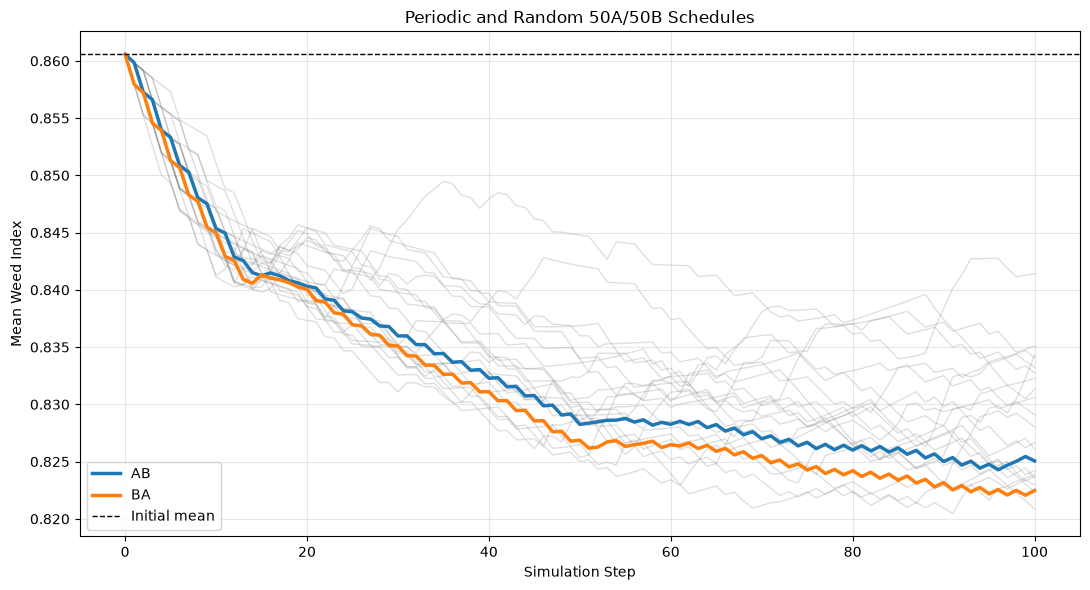

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

for seed, history in random_mean_histories.items():
    ax.plot(
        np.arange(len(history)),
        history,
        color="gray",
        alpha=0.25,
        linewidth=1,
    )

ax.plot(
    deterministic_results["AB"].mean_weed,
    label="AB",
    linewidth=2.5,
)

ax.plot(
    deterministic_results["BA"].mean_weed,
    label="BA",
    linewidth=2.5,
)

ax.axhline(
    baseline_result.initial_mean,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Initial mean",
)

ax.set_title("Periodic and Random 50A/50B Schedules")
ax.set_xlabel("Simulation Step")
ax.set_ylabel("Mean Weed Index")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Define a common-budget policy wrapper

The unrestricted strategies spend different amounts. To make a fair budget
comparison, the smallest unrestricted cost among the active deterministic
strategies is used as the common budget.

When a policy action would exceed the remaining budget, its removal array is
scaled proportionally so that spending stops exactly at the budget limit.

In [15]:
class BudgetLimitedPolicy:
    '''Limit a policy to a fixed cumulative treatment budget.'''

    def __init__(self, policy, budget):
        if not callable(policy):
            raise TypeError("policy must be callable")

        if budget < 0:
            raise ValueError("budget must be non-negative")

        self.policy = policy
        self.budget = float(budget)
        self.spent = 0.0

    def reset(self):
        self.spent = 0.0

        reset_policy = getattr(
            self.policy,
            "reset",
            None,
        )

        if callable(reset_policy):
            reset_policy()

    def __call__(self, weed_grid, valid_mask):
        # Call the underlying policy even after budget exhaustion so that
        # its schedule continues to advance correctly.
        diff, proposed_cost = self.policy(
            weed_grid,
            valid_mask,
        )

        proposed_cost = float(proposed_cost)
        remaining_budget = self.budget - self.spent

        if remaining_budget <= 0 or proposed_cost <= 0:
            return np.zeros_like(
                weed_grid,
                dtype=np.float32,
            ), 0.0

        if proposed_cost <= remaining_budget:
            self.spent += proposed_cost
            return diff, proposed_cost

        scale = remaining_budget / proposed_cost

        scaled_diff = (
            np.asarray(diff, dtype=np.float32)
            * scale
        )

        self.spent = self.budget

        return scaled_diff, remaining_budget

## Run deterministic schedules under an equal budget

The common budget is the smallest unrestricted final cost among A, B, AB,
BA and the two block schedules. This ensures that every active strategy can
be capped at exactly the same maximum expenditure.

In [16]:
active_names = list(schedules)

common_budget = min(
    deterministic_results[name].final_cost
    for name in active_names
)

print(f"Common budget: {common_budget:,.2f}")

budgeted_results = {}

for name, schedule in tqdm(
    schedules.items(),
    total=len(schedules),
    desc="Equal-budget schedules",
):
    budgeted_results[name] = run_schedule(
        name=f"budgeted_{name}",
        schedule=schedule,
        policy_wrapper=lambda policy: BudgetLimitedPolicy(
            policy,
            budget=common_budget,
        ),
    )

budgeted_summary = pd.DataFrame(
    [
        summarise_result(name, result)
        for name, result in budgeted_results.items()
    ]
)

budgeted_summary

Common budget: 277,365.28


Equal-budget schedules: 100%|██████████| 6/6 [00:01<00:00,  4.10it/s]


,strategy,initial_mean,final_mean,relative_change,winning,high_density_cells,cumulative_weed,final_cost
0,A only,0.860575,0.925060,0.074933,False,6933,86.551491,277365.28125
1,B only,0.860575,0.882562,0.025550,False,5474,86.158447,277365.28125
2,AB,0.860575,0.919987,0.069038,False,6078,85.387146,277365.28125
3,BA,0.860575,0.918392,0.067185,False,6044,85.247726,277365.28125
4,A50B50,0.860575,0.908853,0.056101,False,6373,86.630898,277365.28125
5,B50A50,0.860575,0.900147,0.045984,False,6348,85.970261,277365.28125


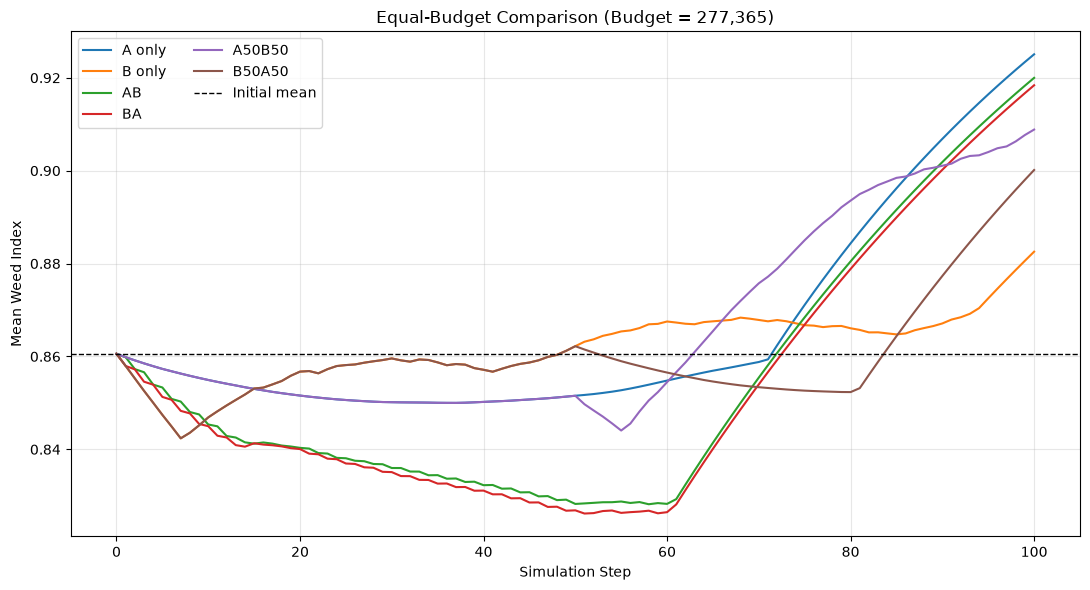

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))

for name, result in budgeted_results.items():
    ax.plot(
        np.arange(len(result.mean_weed)),
        result.mean_weed,
        label=name,
    )

ax.axhline(
    baseline_result.initial_mean,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Initial mean",
)

ax.set_title(
    f"Equal-Budget Comparison (Budget = {common_budget:,.0f})"
)
ax.set_xlabel("Simulation Step")
ax.set_ylabel("Mean Weed Index")
ax.grid(alpha=0.3)
ax.legend(ncol=2)

plt.tight_layout()
plt.show()

## Final classification

The result is classified using three increasingly strong interpretations:

1. **Strict endpoint reversal** — A and B are individually losing while AB
   or BA is winning.
2. **Alternation-specific reversal** — periodic alternation wins while both
   block schedules lose.
3. **Equal-budget alternation advantage** — periodic alternation remains
   better under a common budget.

If block and random schedules perform similarly to AB and BA, the result is
more accurately described as complementary policy mixing. If periodic
alternation remains uniquely effective under an equal budget, the evidence
for a clean Parrondo-type scheduling effect is substantially stronger.

In [18]:
unrestricted_periodic_best = min(
    deterministic_results["AB"].relative_change,
    deterministic_results["BA"].relative_change,
)

unrestricted_block_best = min(
    deterministic_results["A50B50"].relative_change,
    deterministic_results["B50A50"].relative_change,
)

budgeted_periodic_best = min(
    budgeted_results["AB"].relative_change,
    budgeted_results["BA"].relative_change,
)

budgeted_block_best = min(
    budgeted_results["A50B50"].relative_change,
    budgeted_results["B50A50"].relative_change,
)

equal_budget_periodic_winning = (
    budgeted_periodic_best < 0
)

equal_budget_periodic_beats_blocks = (
    budgeted_periodic_best
    < budgeted_block_best
)

final_checks = pd.Series(
    {
        "individual_A_and_B_losing": individual_losing,
        "periodic_AB_or_BA_winning": any(
            periodic_winning.values()
        ),
        "both_block_schedules_losing": not any(
            block_winning.values()
        ),
        "alternation_specific": alternation_specific,
        "random_winning_fraction": random_winning_fraction,
        "equal_budget_periodic_winning": (
            equal_budget_periodic_winning
        ),
        "equal_budget_periodic_beats_blocks": (
            equal_budget_periodic_beats_blocks
        ),
        "unrestricted_periodic_best": (
            unrestricted_periodic_best
        ),
        "unrestricted_block_best": (
            unrestricted_block_best
        ),
        "budgeted_periodic_best": (
            budgeted_periodic_best
        ),
        "budgeted_block_best": (
            budgeted_block_best
        ),
    }
)

final_checks

individual_A_and_B_losing                 True
periodic_AB_or_BA_winning                 True
both_block_schedules_losing              False
alternation_specific                     False
random_winning_fraction                    1.0
equal_budget_periodic_winning            False
equal_budget_periodic_beats_blocks       False
unrestricted_periodic_best           -0.044273
unrestricted_block_best              -0.007963
budgeted_periodic_best                0.067185
budgeted_block_best                   0.045984
dtype: object